### Imports

In [2]:
import kagglehub

path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\raian\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
from sklearn.preprocessing import MinMaxScaler

In [3]:
sample_df = pd.DataFrame({'x': [0,1,2,3,4,5,6,7]})
sample_df

,x
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


In [15]:
pd.concat([sample_df.shift(i).add_suffix(f' (t-{i})') for i in range(lags, 0, -1)] + [sample_df.add_suffix(' (t)')], axis=1).dropna()

,x (t-3),x (t-2),x (t-1),x (t)
3,0.0,1.0,2.0,3
4,1.0,2.0,3.0,4
5,2.0,3.0,4.0,5
6,3.0,4.0,5.0,6
7,4.0,5.0,6.0,7


In [ ]:
df_supervised = pd.concat(
    [df_resample.shift(i).add_suffix(f'(t-{i})') for i in range(lags, 0, -1)] +
    [df_resample.add_suffix('(t)')],
    axis=1
)

### EDA

In [9]:
df = pd.read_csv(os.path.join(path, 'household_power_consumption.txt'), na_values=['nan', '?'], sep=';')
df['dt'] = df['Date'] + ' ' + df['Time']
df = df.set_index('dt')
df = df.drop(['Date', 'Time'], axis=1)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
16/12/2006 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
16/12/2006 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
16/12/2006 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
16/12/2006 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
16/12/2006 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
#convert index col to DatetimeIndex
df.index = pd.to_datetime(df.index, format='%d/%m/%Y %H:%M:%S')
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


In [12]:
# replace nulls with mean values
for col in df.columns:
    df[col] = df[col].fillna(df[col].mean())

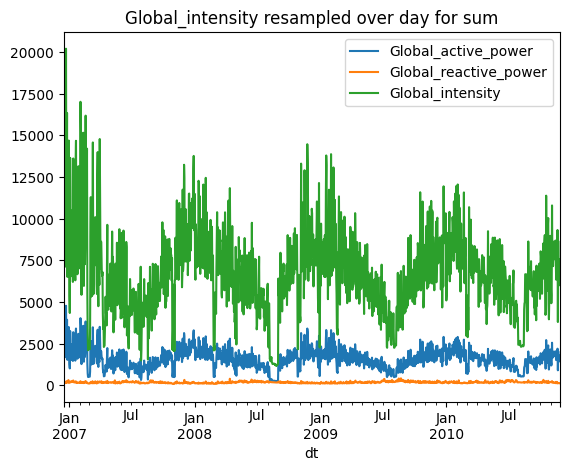

In [16]:
df.Global_active_power.resample('D').sum().plot(title='Global_active_power resampled over day for sum')
df.Global_reactive_power.resample('D').sum().plot(title='Global_reactive_power resampled over day for sum')
df.Global_intensity.resample('D').sum().plot(title='Global_intensity resampled over day for sum')
plt.legend(['Global_active_power', 'Global_reactive_power', 'Global_intensity'])

<Axes: title={'center': 'Global_active_power resampled over month for sum'}, xlabel='dt'>

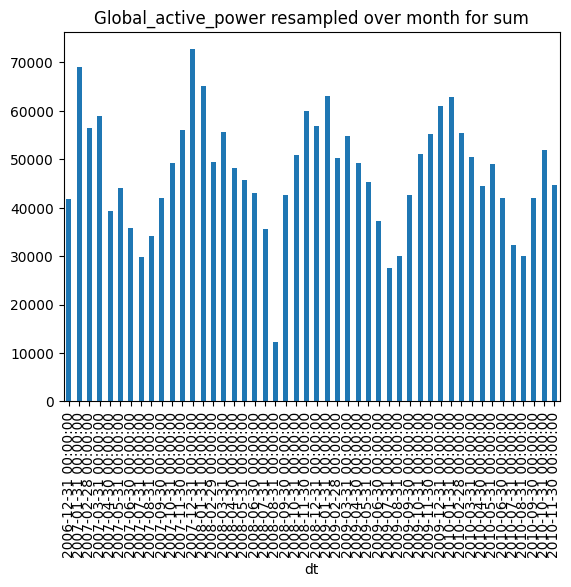

In [19]:
df.Global_active_power.resample('ME').sum().plot(title='Global_active_power resampled over month for sum', kind='bar')

<Axes: title={'center': 'Global_active_power resampled over month for sum'}, xlabel='dt'>

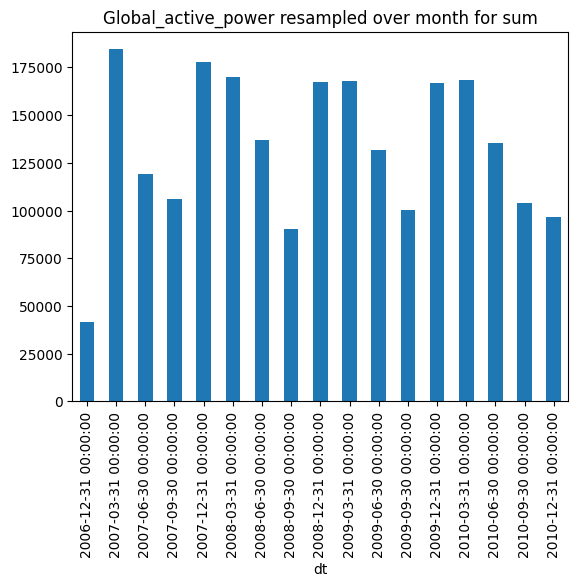

In [22]:
df.Global_active_power.resample('QE').sum().plot(title='Global_active_power resampled over month for sum', kind='bar')

Text(0.5, 1.0, 'Correlation Matrix')

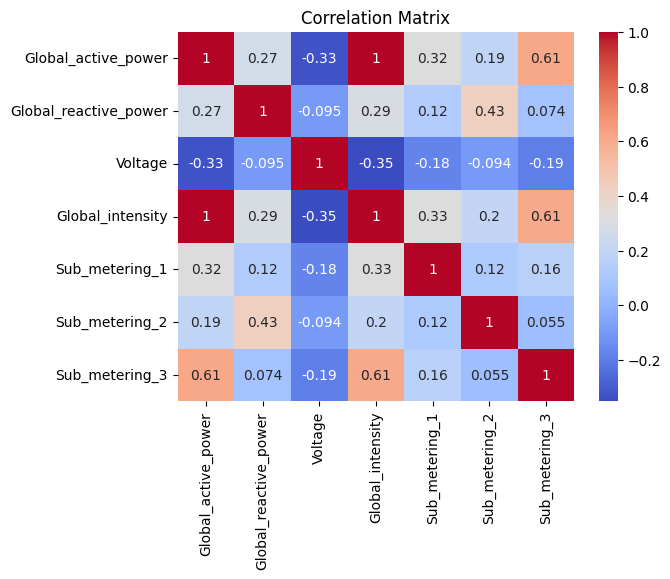

In [30]:
corr_matrix = df.corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

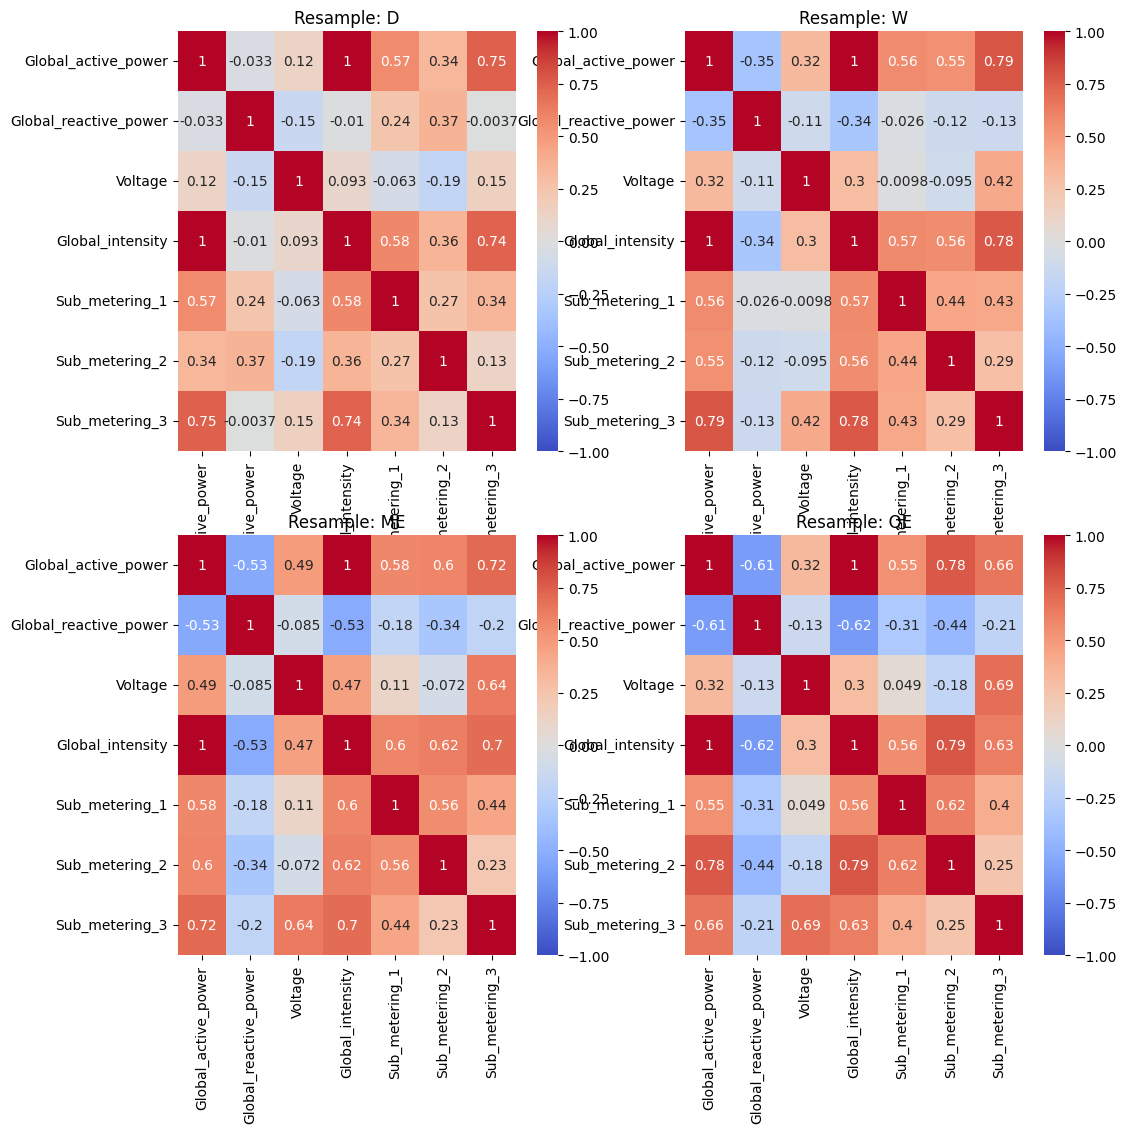

In [39]:
frequencies = ['D', 'W', 'ME', 'QE']
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax = ax.flatten()

for i, freq in enumerate(frequencies):
    corr_matrix = df.resample(freq).mean().corr(method='spearman')
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax[i])
    ax[i].set_title(f'Resample: {freq}')

In [49]:
df_resample = df.resample('h').mean() 
df_resample.shape

(34589, 7)

In [50]:
scaler = MinMaxScaler((0,1))
lags = 3
df_supervised = pd.concat(
    [df_resample.shift(i).add_suffix(f'(t-{i})') for i in range(lags, 0, -1)] +
    [df_resample.add_suffix('(t)')],
    axis=1
).dropna()


df_supervised.drop(df_supervised.columns[[8,9,10,11,12,13]], axis=1, inplace=True)
df_supervised.head()

,Global_active_power(t-3),Global_reactive_power(t-3),Voltage(t-3),Global_intensity(t-3),Sub_metering_1(t-3),Sub_metering_2(t-3),Sub_metering_3(t-3),Global_active_power(t-2),Global_active_power(t-1),Global_reactive_power(t-1),...,Sub_metering_1(t-1),Sub_metering_2(t-1),Sub_metering_3(t-1),Global_active_power(t),Global_reactive_power(t),Voltage(t),Global_intensity(t),Sub_metering_1(t),Sub_metering_2(t),Sub_metering_3(t)
dt,,,,,,,,,,,,,,,,,,,,,
2006-12-16 20:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,3.632200,3.400233,0.085233,...,0.0,1.433333,16.683333,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.400233,3.268567,0.075100,...,0.0,0.000000,16.783333,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667
2006-12-16 22:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.268567,3.056467,0.076667,...,0.0,0.416667,17.216667,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333
2006-12-16 23:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.056467,2.200133,0.056167,...,0.0,0.133333,4.433333,2.061600,0.071433,240.619667,8.896667,0.0,0.083333,0.000000
2006-12-17 00:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2.200133,2.061600,0.071433,...,0.0,0.083333,0.000000,1.882467,0.102433,240.961833,8.126667,0.0,0.466667,0.000000


In [58]:
values = df_supervised.values
split = int(len(df_supervised) * 0.8)

train = values[:split, :]
test = values[split:, :]

x_train, y_train = train[:, :-1], train[:, -1]
x_test, y_test = test[:, :-1], test[:, -1]

In [59]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
x_test = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))

print("train_X:", x_train.shape)
print("train_y:", y_train.shape)
print("test_X:", x_test.shape)
print("test_y:", y_test.shape)

train_X: (27668, 1, 21)
train_y: (27668, 1)
test_X: (6918, 1, 21)
test_y: (6918, 1)


### ML

In [67]:
import torch
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(torch.tensor(x_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_ds, 16, shuffle=False)
test_loader = DataLoader(test_ds, 16, shuffle=False)

In [69]:
import torch.nn as nn
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, 3, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :] #(batch, time, features)
        x = self.head(x)
        return x

In [74]:
from torch.optim import AdamW
model = LSTMModel(x_train.shape[2])
criterion = nn.MSELoss()
optim = AdamW(model.parameters(), lr=1e-3)
model

LSTMModel(
  (lstm): LSTM(21, 64, num_layers=3, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [76]:
from tqdm.auto import tqdm
epochs = 20
model.train()
for epoch in tqdm(range(epochs)):
    train_loss = 0
    for x, y in train_loader:
        preds = model(x)
        loss = criterion(preds, y)

        loss.backward()
        optim.step()

        train_loss += loss.item()

        optim.zero_grad()

100%|██████████| 20/20 [01:47<00:00,  5.39s/it]


In [77]:
model.eval()

preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        out = model(X_batch)
        preds.append(out)

preds = torch.cat(preds).numpy()

In [ ]:
preds_rescaled = scaler_y.inverse_transform(preds)
y_test_rescaled = scaler_y.inverse_transform(y_test)

In [84]:
y_test_rescaled[3]

array([13.91666667])

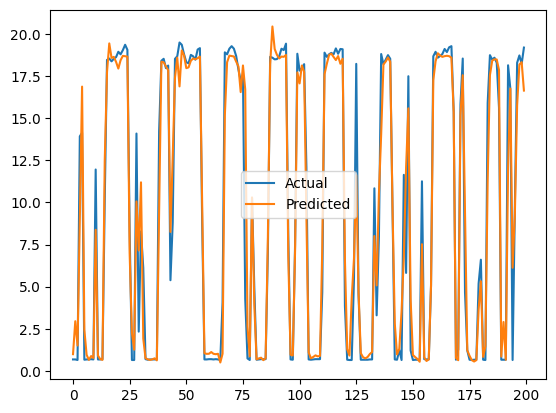

In [86]:
import matplotlib.pyplot as plt

plt.plot(y_test_rescaled[:200], label='Actual')
plt.plot(preds_rescaled[:200], label = 'Predicted')
plt.legend()
plt.show()